# Explore Co-elution dataset

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

## Load in co-elution

In [2]:
coelution = pd.read_csv('data/coelution/repl1_repl2_combined.tsv', sep = '\t', index_col = 0)
coelution.head()

,repl1_1,repl1_2,repl1_3,repl1_4,repl1_5,repl1_6,repl1_7,repl1_8,repl1_9,repl1_10,...,repl2_63,repl2_64,repl2_65,repl2_66,repl2_67,repl2_68,repl2_69,repl2_70,repl2_71,repl2_72
xxx,,,,,,,,,,,,,,,,,,,,,
0002Y95AH,NaN,NaN,NaN,2.263669,22.128841,51.762737,52.550846,49.825542,48.441952,62.953640,...,553.849060,274.200378,286.662445,112.624908,47.87561,59.853748,63.270977,27.508387,30.672783,32.651031
00BDGD39O,NaN,NaN,4.324259,19.600451,80.607506,172.490936,179.236649,158.082748,139.140900,114.486351,...,4.175920,NaN,3.220537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
00BXY8FC6,NaN,NaN,5.754857,11.839447,53.564465,89.967712,76.064796,87.056900,74.854607,62.707325,...,4.823446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
00GQL2IWT,NaN,NaN,NaN,2.807737,13.327758,24.826971,23.496061,25.944332,24.684835,21.924423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
00W2KCFX9,NaN,NaN,3.518204,7.602578,29.471481,78.761925,75.764984,56.365299,48.396515,47.562271,...,NaN,4.695970,3.909930,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Load in coelution_onecluster.csv and filter coelution

In [5]:
onecluster = pd.read_csv('coelution_onecluster.csv')
oneclust_proteins = list(onecluster["xxx"])

coelution = coelution[(coelution.index.isin(oneclust_proteins))]
len(coelution)

2341

In [6]:
coelution.head()

,repl1_1,repl1_2,repl1_3,repl1_4,repl1_5,repl1_6,repl1_7,repl1_8,repl1_9,repl1_10,...,repl2_63,repl2_64,repl2_65,repl2_66,repl2_67,repl2_68,repl2_69,repl2_70,repl2_71,repl2_72
xxx,,,,,,,,,,,,,,,,,,,,,
0002Y95AH,NaN,NaN,NaN,2.263669,22.128841,51.762737,52.550846,49.825542,48.441952,62.953640,...,553.849060,274.200378,286.662445,112.624908,47.87561,59.853748,63.270977,27.508387,30.672783,32.651031
00BXY8FC6,NaN,NaN,5.754857,11.839447,53.564465,89.967712,76.064796,87.056900,74.854607,62.707325,...,4.823446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
03EH72R04,NaN,NaN,2.602626,1.398568,21.967245,52.687645,53.346279,59.228928,66.631607,65.737228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
03Q63121B,NaN,NaN,NaN,5.127691,25.225914,40.962234,50.816757,44.342518,35.773361,31.892586,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
04AO5B0HC,NaN,NaN,NaN,2.243110,37.892437,98.358467,134.426819,130.394592,127.796410,115.092514,...,NaN,4.312362,7.246211,NaN,NaN,NaN,NaN,NaN,2.032157,1.261086


## Create a Correlation Matrix for the Co-Elution Data

In [7]:
coelution = coelution.transpose()
coelution.head()

xxx,0002Y95AH,00BXY8FC6,03EH72R04,03Q63121B,04AO5B0HC,04KORE5KO,05JUOSEAW,06172T8B9,067DQOPQJ,06UKJIB8G,...,ZW55Z2DCG,ZWG2K4WR7,ZWPNO151P,ZWZ86JKHP,ZX5AYJ7LG,ZY03X5QEH,ZY8TJP5HW,ZYB2XIVKR,ZYOOMGYJ0,ZZBWF4AM0
repl1_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.617664
repl1_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.611198
repl1_3,NaN,5.754857,2.602626,NaN,NaN,5.312474,NaN,2.562765,NaN,3.543056,...,NaN,13.645734,4.511442,NaN,2.512764,1.770480,NaN,1.883994,NaN,26.039371
repl1_4,2.263669,11.839447,1.398568,5.127691,2.243110,43.135357,NaN,9.475479,13.080009,9.692546,...,4.654689,45.942749,7.233143,NaN,11.740929,6.976587,9.379194,NaN,NaN,137.779861
repl1_5,22.128841,53.564465,21.967245,25.225914,37.892437,170.817886,5.618252,28.043308,62.127926,48.804237,...,NaN,167.640762,49.660778,12.465476,55.385868,22.258337,24.721781,25.423836,10.377205,802.066101


In [8]:
corr_matrix = coelution.corr(min_periods=3)
corr_matrix = corr_matrix.fillna(0)
with open("data/coelution/correlation_matrix.pkl", "wb") as handle:
    pickle.dump(corr_matrix, handle)

In [9]:
corr_matrix

xxx,0002Y95AH,00BXY8FC6,03EH72R04,03Q63121B,04AO5B0HC,04KORE5KO,05JUOSEAW,06172T8B9,067DQOPQJ,06UKJIB8G,...,ZW55Z2DCG,ZWG2K4WR7,ZWPNO151P,ZWZ86JKHP,ZX5AYJ7LG,ZY03X5QEH,ZY8TJP5HW,ZYB2XIVKR,ZYOOMGYJ0,ZZBWF4AM0
xxx,,,,,,,,,,,,,,,,,,,,,
0002Y95AH,1.000000,-0.048663,-0.135088,0.129942,-0.138356,-0.095605,-0.175904,-0.132834,0.153528,-0.201199,...,-0.194053,-0.280718,0.026719,0.569230,-0.183233,-0.118176,-0.106416,-0.010685,0.496186,-0.183936
00BXY8FC6,-0.048663,1.000000,0.064430,-0.253349,0.815497,-0.095777,-0.025193,-0.269651,-0.129339,-0.138533,...,0.328688,-0.303531,0.108412,0.387632,-0.138046,-0.235853,-0.017276,0.958233,-0.163418,-0.104078
03EH72R04,-0.135088,0.064430,1.000000,-0.368536,0.020128,0.076887,-0.078368,-0.281887,0.000923,0.101334,...,-0.125338,-0.098596,0.304453,0.336171,-0.075761,-0.286703,-0.034818,-0.030146,-0.128224,-0.006558
03Q63121B,0.129942,-0.253349,-0.368536,1.000000,0.301384,-0.018796,0.143617,-0.109635,0.588572,0.774182,...,-0.438576,0.378547,0.258675,0.629428,0.763303,0.781493,0.748956,-0.040119,0.596609,0.948910
04AO5B0HC,-0.138356,0.815497,0.020128,0.301384,1.000000,-0.126922,-0.004031,-0.258784,0.122817,0.078163,...,0.377199,-0.161664,0.292236,0.354203,0.081494,0.284634,0.195329,0.847379,0.159427,0.199037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZY03X5QEH,-0.118176,-0.235853,-0.286703,0.781493,0.284634,-0.218634,0.055037,0.194984,0.423983,0.827478,...,-0.343505,0.604659,0.279963,0.116375,0.706789,1.000000,0.489325,0.022645,0.039883,0.880647
ZY8TJP5HW,-0.106416,-0.017276,-0.034818,0.748956,0.195329,-0.054779,-0.141240,-0.116556,0.647100,0.596285,...,-0.147688,0.209360,0.523259,0.644626,0.757171,0.489325,1.000000,0.038235,0.824764,0.760685
ZYB2XIVKR,-0.010685,0.958233,-0.030146,-0.040119,0.847379,-0.116129,-0.027196,-0.270182,-0.080915,-0.103464,...,0.419399,-0.327699,0.134387,0.678017,-0.066589,0.022645,0.038235,1.000000,-0.032845,-0.068020


## Histogram of Clusters

In [10]:
from collections import Counter

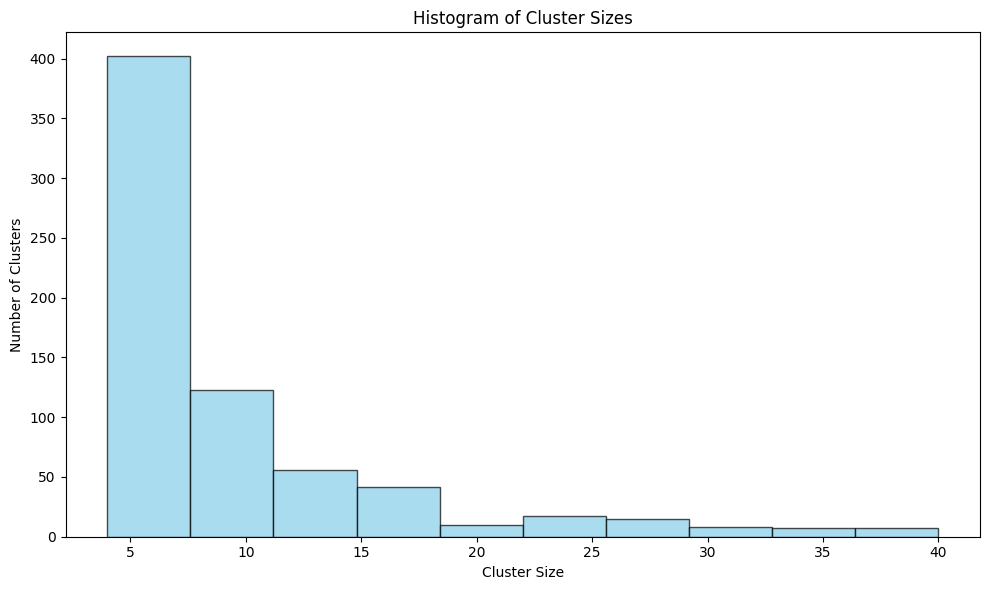

In [34]:
clusters = pd.read_csv("coelution_hidef_clusters_nn6.csv")
clusters = list(clusters["prediction"])

string_counts = Counter(clusters)
frequencies = list(string_counts.values())
    
plt.figure(figsize=(10, 6))
plt.hist(frequencies, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Cluster Size')
plt.ylabel('Number of Clusters')
plt.title('Histogram of Cluster Sizes')
plt.tight_layout()
    
plt.show()